In [1]:
import numpy as np
from numpy.lib.stride_tricks import as_strided

print("=== THE BLACK MAGIC OF STRIDES ===")

# 1. The Setup (float32 = 4 bytes per number)
raw_data = np.array([10, 20, 30, 40, 50], dtype=np.float32)

print(f"Original RAM: {raw_data}")
print(f"Original Strides: {raw_data.strides} bytes\n")

# 2. THE GOAL: We want to create a 3x3 Sliding Window like this:
# [[10, 20, 30],
#  [20, 30, 40],
#  [30, 40, 50]]

# 3. THE BLACK MAGIC (Zero-Copy)
# Normal 3x3 strides would be (12, 4) -> Jump 12 bytes for a new row.
# We hack the C-Engine and tell it: "Jump only 4 bytes for a new row!"
hacked_window = as_strided(raw_data, shape=(3, 3), strides=(4, 4))

print("Hacked Sliding Window View:")
print(hacked_window)

# 4. THE PROOF OF ZERO-COPY
print(f"\nShares Memory? : {np.shares_memory(raw_data, hacked_window)}")

# 5. IN-PLACE MUTATION TEST
hacked_window[1, 1] = 999.0 # Changing the middle element (30)

print(f"\nAfter Mutation - Hacked Window:\n{hacked_window}")
print(f"After Mutation - Original RAM : {raw_data}")

=== THE BLACK MAGIC OF STRIDES ===
Original RAM: [10. 20. 30. 40. 50.]
Original Strides: (4,) bytes

Hacked Sliding Window View:
[[10. 20. 30.]
 [20. 30. 40.]
 [30. 40. 50.]]

Shares Memory? : True

After Mutation - Hacked Window:
[[ 10.  20. 999.]
 [ 20. 999.  40.]
 [999.  40.  50.]]
After Mutation - Original RAM : [ 10.  20. 999.  40.  50.]


In [12]:
print("="*50)
print("🚀 MISSION 1: THE MEMORY STRIDE HACKER")
print("="*50)

# 1. Create a simple 1D array (Stored contiguously in memory)
arr_1d = np.arange(1, 10, dtype=np.int32).reshape(3, 3)
print(f"Original 1D Array:\n{arr_1d}")
print(f"Original Strides: {arr_1d.strides} bytes") 
# (Since dtype is int32, each element takes 4 bytes. Stride = (4,) bytes)

print("\n--- The Move: as_strided ---")
# 2. Tricking the C-engine to view this as a 3x3 array without copying data.
# Shape = (3, 3) 
# Strides = (8, 4) -> (Jump 8 bytes for the next row, 4 bytes for the next column)

window_2d = as_strided(
    arr_1d, 
    shape=(3, 3), 
    strides=(8, 4)  # 8 bytes (2 items) row jump, 4 bytes (1 item) column jump
)

print(f"Strided 2D Array (Sliding Window):\n{window_2d}")
print(f"Strided Array Strides: {window_2d.strides} bytes")

print("\n--- The Ultimate Proof (Zero-Copy) ---")
# 3. Proving that both arrays point to the exact same memory location
print(f"Is window_2d sharing memory with arr_1d? -> {np.may_share_memory(arr_1d, window_2d)}")

# 4. The Magic Mutation (Manipulation without iteration)
print("\nMutating the first element of the Strided Array to 999...")
window_2d[0, 0] = 999

print(f"Look at the Original 1D Array now:\n{arr_1d}")

🚀 MISSION 1: THE MEMORY STRIDE HACKER
Original 1D Array:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Original Strides: (12, 4) bytes

--- The Move: as_strided ---
Strided 2D Array (Sliding Window):
[[1 2 3]
 [3 4 5]
 [5 6 7]]
Strided Array Strides: (8, 4) bytes

--- The Ultimate Proof (Zero-Copy) ---
Is window_2d sharing memory with arr_1d? -> True

Mutating the first element of the Strided Array to 999...
Look at the Original 1D Array now:
[[999   2   3]
 [  4   5   6]
 [  7   8   9]]


![WhatsApp Image 2026-09-10 at 16.00.45.jpeg](<attachment:WhatsApp Image 2026-09-10 at 16.00.45.jpeg>)
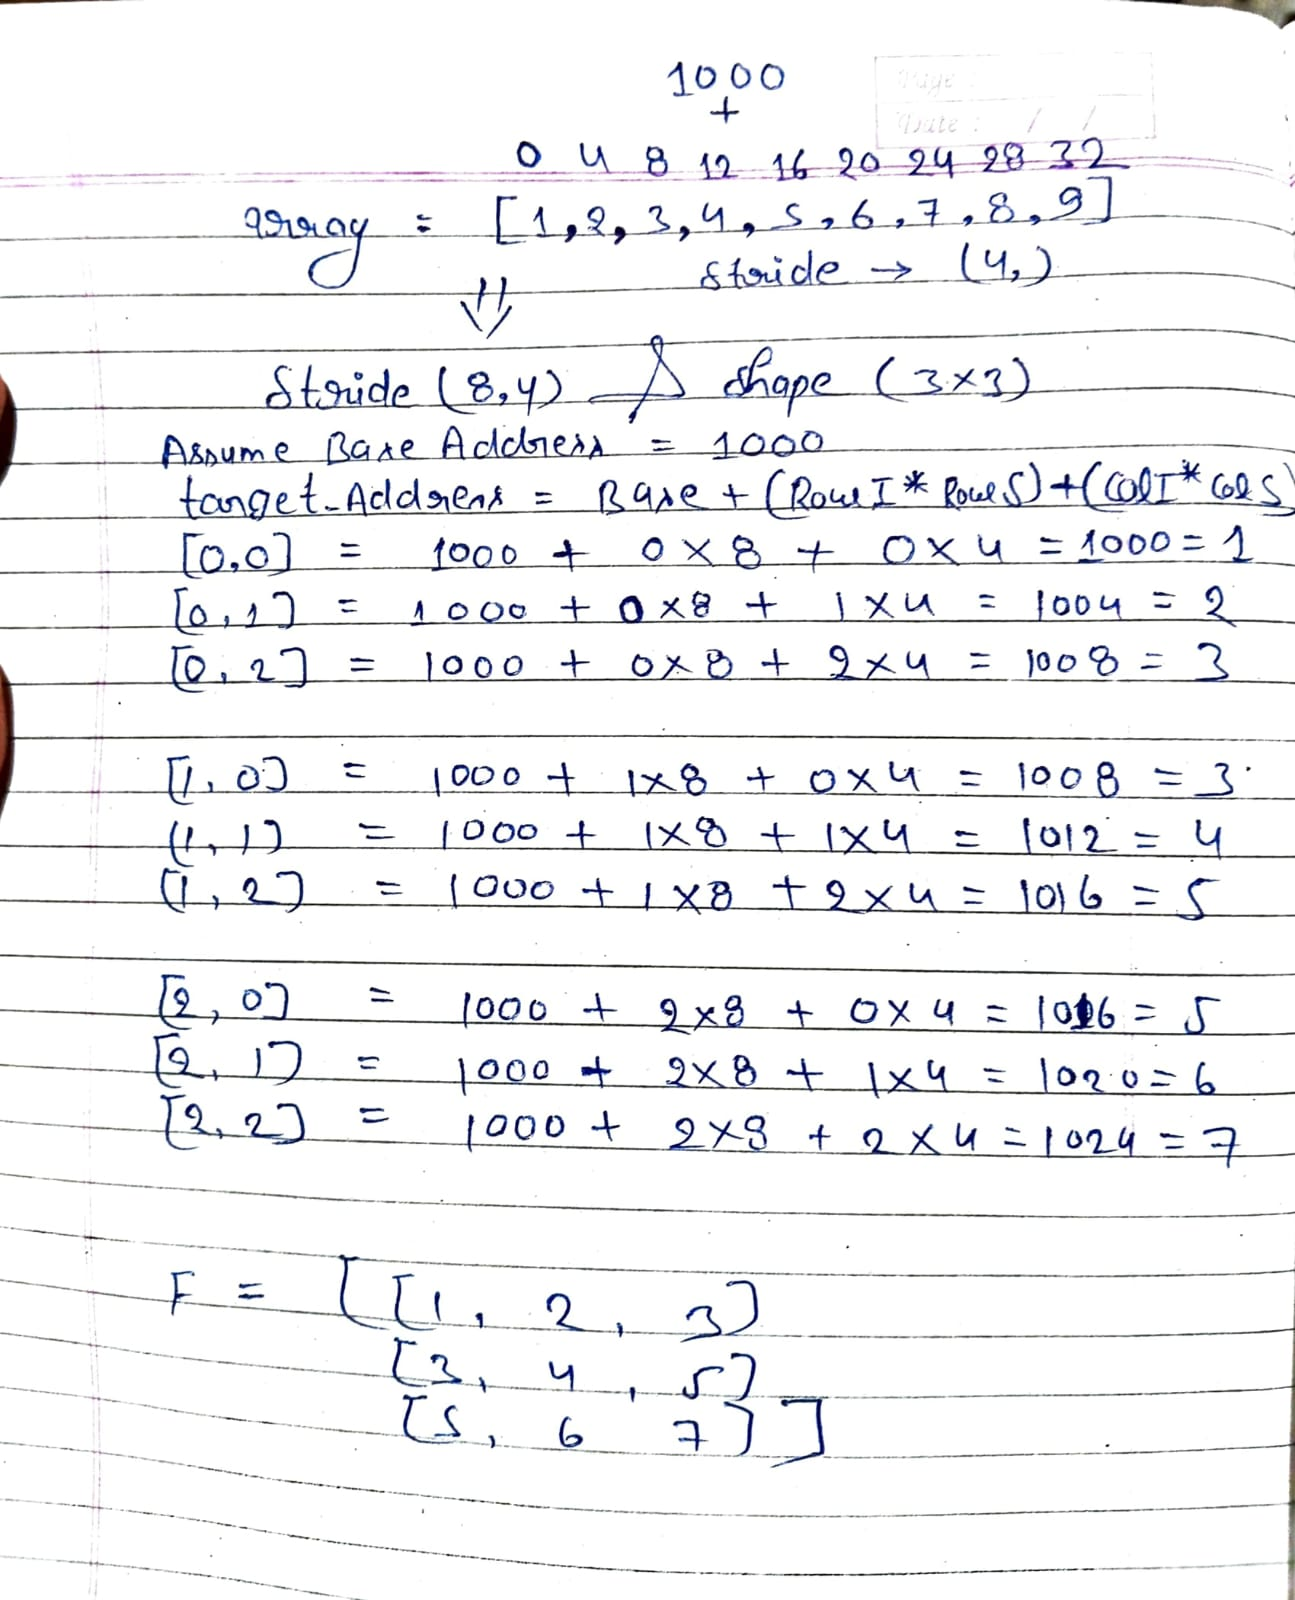

# 🧠 Architect's Note: The Core Reality of Memory & Strides
*A First-Principles deep dive into how CPython and NumPy handle memory allocation, indexing, and the ultimate speed trade-off.*

## 1. The Hardware Reality: RAM is strictly 1D
It is a fundamental hardware truth that **RAM (Random Access Memory) is always 1-Dimensional**. There is no physical concept of a 2D grid or a 3D matrix in hardware; it is simply a long, continuous tape of memory addresses. 
* Any N-Dimensional array you create is just an illusion. 
* NumPy takes a contiguous 1D block of memory and wraps it with a metadata layer containing **Shape** and **Strides**. The data never moves; only the "viewing lens" changes.

## 2. The $O(1)$ Stride Formula
When you request an element like `array[2, 1]`, the CPU does not loop through the array. It calculates the exact memory location instantly using pointer arithmetic.

The internal C-engine calculates the target address as follows:
$$ \text{Target\_Address} = \text{Base\_Address} + (\text{Row}_i \times \text{Row}_{\text{stride}}) + (\text{Col}_i \times \text{Col}_{\text{stride}}) $$

By manipulating these strides manually (e.g., using `numpy.lib.stride_tricks.as_strided`), we can transform 1D arrays into 2D or 3D sliding windows in $O(1)$ time and $O(1)$ space, achieving true **Zero-Copy manipulation**.

## 3. The Truth About Python Lists (CPython Architecture)
While it is commonly said that "Strides don't work on Python lists," the internal architecture of CPython tells a different story. 
* **The `PyObject*` Array:** A Python list is not an array of data; it is an **Array of Pointers** (memory addresses) pointing to the actual data scattered across the heap.
* **Internal Strides Do Exist:** To find `list[2]`, the C-backend still uses a stride. On a 64-bit system, every pointer is exactly 8 bytes. The engine calculates `Base_Address + (Index * 8 bytes)` to find the pointer. 

## 4. The Ultimate Trade-Off: Speed vs. Flexibility
If Python lists use contiguous arrays of pointers and internal strides, why are they slow compared to NumPy?
* **NumPy (Cache Hits):** Stride arithmetic leads directly to the raw data (contiguous memory), making it incredibly fast for CPU caching.
* **Python Lists (Cache Misses):** Stride arithmetic only leads to a pointer. The CPU must then perform **Pointer Dereferencing**—jumping to a completely different location in the RAM to fetch the actual value. 

Python intentionally sacrificed processing speed and cache locality to gain the flexibility of storing heterogeneous data types in a single list.

# 🧠 Architect's Note: Advanced Memory, OS, and Pointers
*A First-Principles exploration of Byte-Addressability, Virtual Memory, and Array Allocation mechanics.*

## 1. Byte-Addressable RAM & Custom Data Types
There is no such thing as fixed "20-byte blocks" inherently built into RAM. RAM is **Byte-Addressable**, meaning every single memory address holds exactly 1 Byte. 
* If a custom data type requires 25 bytes, the OS allocates 25 consecutive addresses in the RAM. 
* The `Stride` for this array simply becomes `25`. 
* To access `Index 2`, the CPU calculates: $\text{Target} = \text{Base} + (2 \times 25)$, jumping exactly 50 bytes ahead.

## 2. The "Largest Item Wins" Rule (Fixed-Width Allocation)
For an array to maintain its $O(1)$ lookup speed, the stride (jump size) must be perfectly uniform. But what happens if a C-array or NumPy array contains items of different sizes (e.g., 1 byte, 3 bytes, and 10 bytes)?
* The system enforces the **"Largest Item Wins"** rule. 
* The Stride is locked to the size of the largest element (10 bytes). 
* The smaller items are padded with empty space to match this 10-byte block. This guarantees the mathematical formula for indexing never fails.

## 3. The 2GB + 1 Byte Problem: The Birth of Pointers
Consider an extreme scenario: We want to store one item of 2GB and two items of 1 byte in a single array. 
* **The C-Array Problem:** If stored as raw data, the "Largest Item Wins" rule would force the OS to allocate 2GB for *every* item. The array would consume 6GB of RAM, wasting roughly 4GB on empty padding.
* **The Python List Solution (Pointers):** To avoid this massive memory waste, engineers decoupled the data from the array. The array no longer stores raw data; it only stores **Pointers (Memory Addresses)**. 
* Since every pointer on a 64-bit system is exactly **8 Bytes**, the array only consumes 24 Bytes (3 blocks of 8 bytes). The actual 2GB and 1-byte data objects are stored randomly in the heap. 

## 4. Virtual Memory vs. Physical Fragmentation
If the physical RAM is highly fragmented (scattered with small data) and we request a massive contiguous NumPy array, the program does *not* crash with a `MemoryError`. This is thanks to **Virtual Memory (Paging)**.
* **The Illusion:** The Operating System provides NumPy with a "Virtual Address Space"—a fake, perfectly contiguous map of memory. NumPy happily applies its $O(1)$ Stride mathematics here.
* **The MMU (Memory Management Unit):** The hardware CPU contains an MMU chip. As NumPy jumps across its fake virtual addresses, the MMU instantly translates these to the scattered physical addresses in the actual RAM.

## 5. Why Not Compact Memory in the OS?
If the MMU requires translation, why doesn't the OS just shift the scattered data together (defragmentation) to make it physically contiguous and save time?
1. **The $O(N)$ Cost:** Shifting gigabytes of data takes milliseconds, freezing the entire system.
2. **The Pointer Nightmare (SegFaults):** If the OS moves data, every pointer in every program pointing to that data becomes invalid. Accessing the old address would cause a Segmentation Fault.
3. **The TLB Solution:** Instead of shifting data, engineers built the **TLB (Translation Lookaside Buffer)** inside the CPU. It caches translations, making the MMU process take nanoseconds (effectively zero delay).

## 6. The $O(N)$ Size Calculation vs. Static Typing
If the OS needs to create blocks based on the "Largest Item Wins" rule, does it run an $O(N)$ loop across millions of items to find the largest one before allocating memory? 

**The $O(1)$ Bypass: Static Typing (`dtype`)**
In lower-level implementations (C, C++, or NumPy), the CPU avoids this costly $O(N)$ scan entirely by enforcing **Static Typing**. 
* When you declare a NumPy array as `int32`, the engine instantly knows every block must be exactly 4 Bytes. 
* It blindly allocates 4-byte blocks in $O(1)$ time. 
* If an item exceeds this limit, the system does not resize the blocks; it immediately throws an **Overflow Error**.

**The $O(N)$ Reality: NumPy String Arrays**
However, the $O(N)$ scan theory becomes 100% accurate when dealing with variable-length, dynamically typed data in NumPy—specifically, String arrays.
* If you pass a list like `["A", "Apple", "Elephant"]` to `np.array()` without specifying a fixed size, NumPy is forced to calculate the max width.
* The engine runs an $O(N)$ loop to find the longest string (e.g., "Elephant" = 8 characters).
* It then sets the Stride to accommodate 8 characters for *every* element, padding shorter strings like "A" with empty memory to maintain the contiguous $O(1)$ lookup structure.

## 7. The Python List Exemption (Fixed-Size Pointers)
If NumPy string arrays suffer from the $O(N)$ size-calculation loop, do Python lists suffer from the same problem when storing variable-sized objects?

**The Answer is No.**
Python lists completely bypass this $O(N)$ size-calculation loop. Because a Python list is fundamentally an array of memory addresses (`PyObject*` pointers), the CPython engine already knows the exact size of every element: exactly **8 Bytes** (on a 64-bit architecture).

* Whether you append a 1-byte boolean or a 2GB custom object to a Python list, the list itself only stores the 8-byte pointer. 
* Therefore, to allocate memory for a list of `N` items, the CPU instantly allocates exactly `N * 8` bytes in $O(1)$ time. 

This brilliantly demonstrates Python's ultimate architectural trade-off: it sacrificed the contiguous cache-locality of raw data to achieve $O(1)$ memory allocation and absolute flexibility for heterogeneous (mixed) data types.

*(Note: While the OS avoids shifting data, high-level languages like Python and Java use a controlled version of this called the **"Mark and Compact" Garbage Collector** to periodically pause the program and clean up memory gaps.)*